In [1]:
!mamba install pandas numpy matplotlib seaborn scipy scikit-learn

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.101 seconds
  Name                Version    Build                Channel
---------------------------------------------------------------------------
+ brotli-python       1.2.0      py313ha26e73d_2      emscripten-forge-4x
+ certifi             2026.7.22  pyhd8ed1ab_0         conda-forge
+ charset-normalizer  3.5.1      pyhd8ed1ab_0         conda-forge
+ idna                3.19       pyhcf101f3_0         conda-forge
+ joblib              1.6.0      py313h57e9779_0      emscripten-forge-4x
+ narwhals            2.25.0     pyhcf101f3_0         conda-forge
+ pandas              3.0.5      np23py313h1e705a5_0  emscripten-forge-4x
+ patsy               1.0.3      py313h1804a44_0      emscripten-forge-4x
+ pysocks             1.7.1      py313h1804a44_3      emscripten-forge-4x
+ p

### 1. בחירת הנתונים ותיאורם (Dataset Selection)

**מקור הנתונים ואיסופם**
עבור ניתוח זה של למידה בלתי מונחית וזיהוי אנומליות, בחרתי להשתמש במאגר הנתונים "California Housing". זהו דאטה-סט המבוסס על נתוני מפקד האוכלוסין של קליפורניה משנת 1990.

**מטרת האיסוף ומי אסף**
הנתונים נאספו על ידי לשכת מפקד האוכלוסין של ארה"ב (U.S. Census Bureau) במטרה לתעד מדדים דמוגרפיים ונתוני דיור ברחבי אזורי מגורים שונים בקליפורניה. הנתונים משמשים רבות בלמידת מכונה לחקר תבניות סוציואקונומיות.

**משמעות המאפיינים (Features)**
הדאטה-סט מכיל 8 מאפיינים מספריים המתארים את קבוצות הבלוקים (אזורי מגורים):
* **MedInc:** הכנסה חציונית באזור.
* **HouseAge:** חציון גיל הבתים באזור.
* **AveRooms & AveBedrms:** ממוצע חדרים וחדרי שינה למשק בית.
* **Population & AveOccup:** אוכלוסיית האזור וממוצע נפשות למשק בית.
* **Latitude & Longitude:** קואורדינטות גיאוגרפיות (קווי רוחב ואורך).
*(הערה: כדי לעמוד באופן קפדני בעקרונות של למידה בלתי מונחית, עמודת המטרה המייצגת את מחיר הבית החציוני הוסרה מהנתונים).*

**מגבלות והטיות אפשריות (Limitations and Biases)**
1. **הטיה זמנית (Temporal Bias):** הנתונים הם משנת 1990, כך שהנוף הכלכלי והדמוגרפי השתנה משמעותית מאז.
2. **מגבלה גיאוגרפית:** הנתונים מכסים רק את מדינת קליפורניה, בעלת מאפייני נדל"ן ודמוגרפיה ייחודיים שאינם בהכרח מייצגים אזורים אחרים בעולם.
3. **אגרגציה:** הנתונים מקובצים ברמת ה"בלוק" (אזור) ולא ברמת הבית הבודד, מה שעשוי "להחליק" ולהסתיר אנומליות נקודתיות של בתים ספציפיים.

--- Structural Analysis ---
Number of rows and columns: (20640, 8)

Data Types:
MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
dtype: object

Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64

Statistical Summary:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


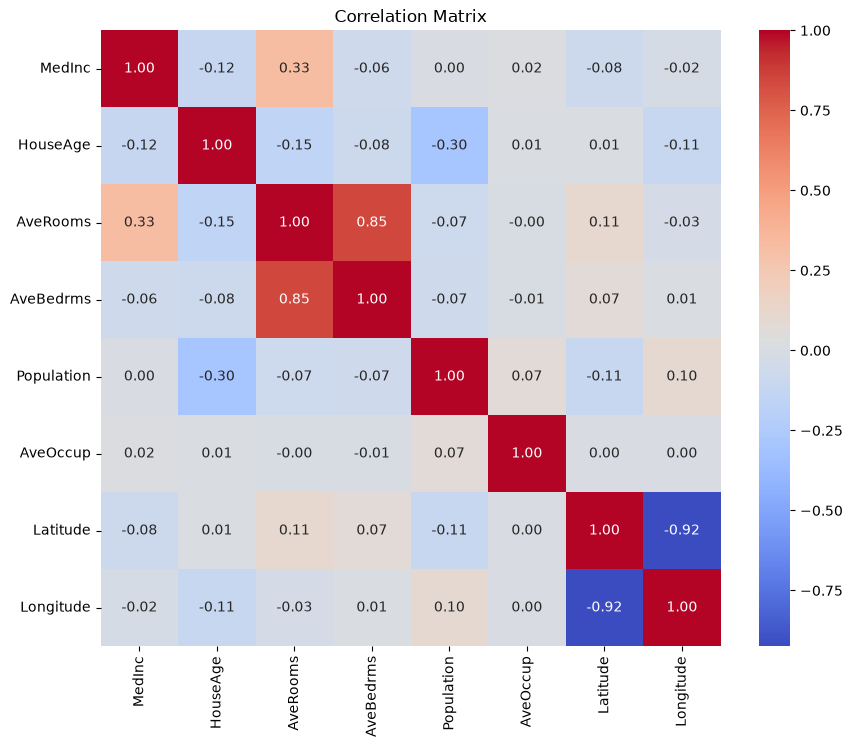


--- Distribution Analysis (Skewness & Kurtosis) ---

Feature: MedInc
Skewness: 1.65, Kurtosis: 4.95


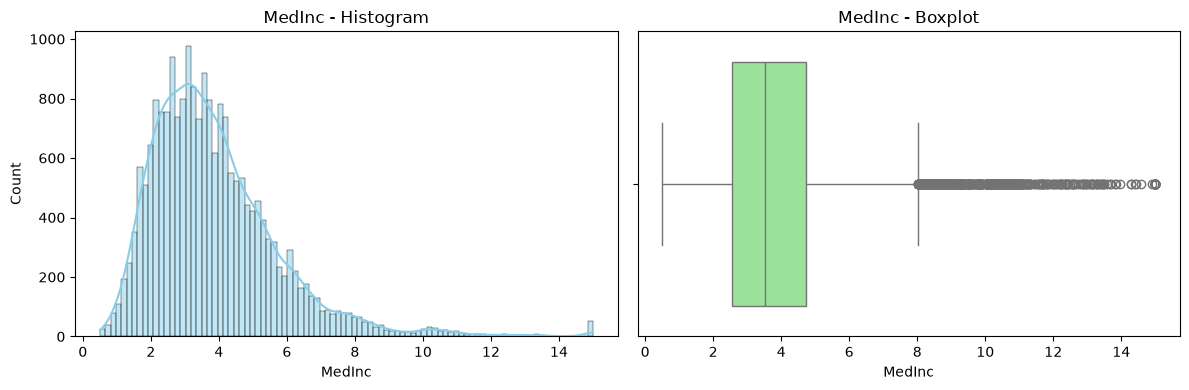


Feature: HouseAge
Skewness: 0.06, Kurtosis: -0.80


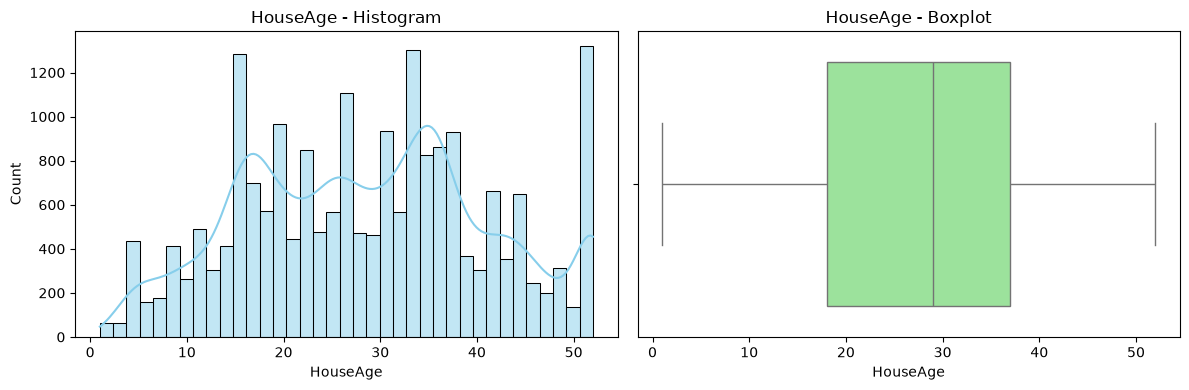


Feature: AveRooms
Skewness: 20.70, Kurtosis: 879.14


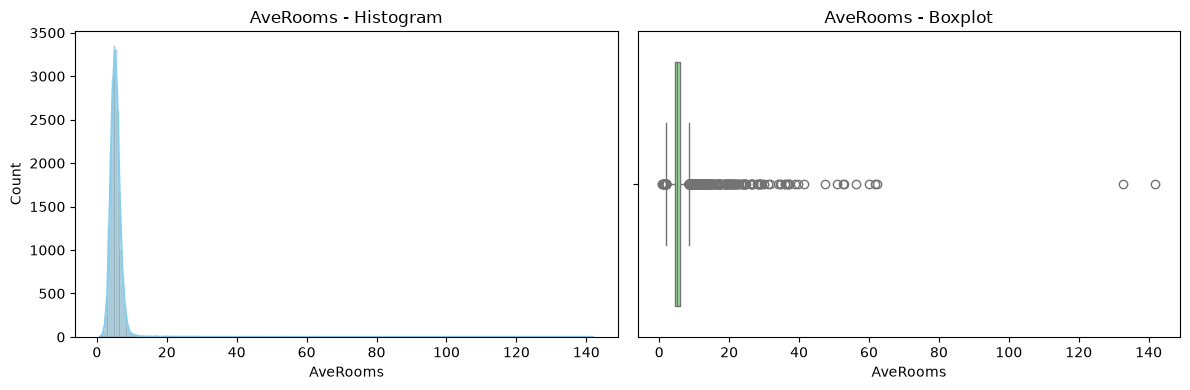


Feature: AveBedrms
Skewness: 31.31, Kurtosis: 1636.32


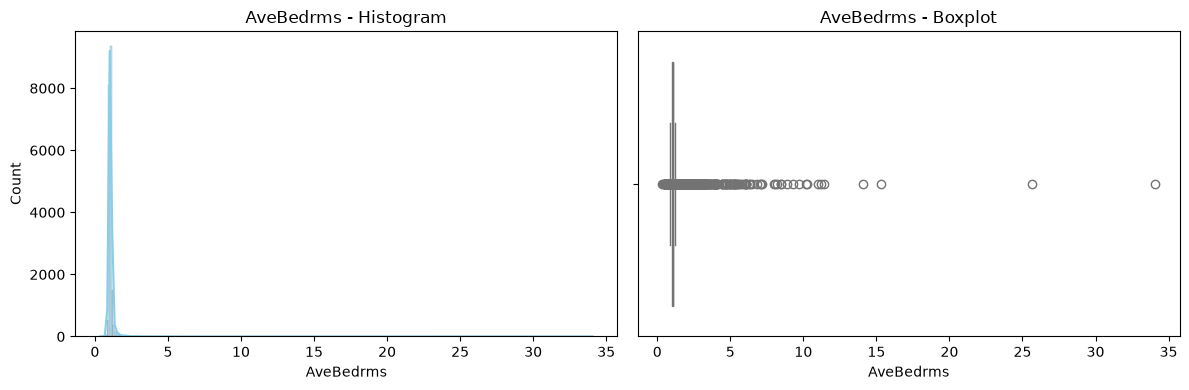


Feature: Population
Skewness: 4.94, Kurtosis: 73.54


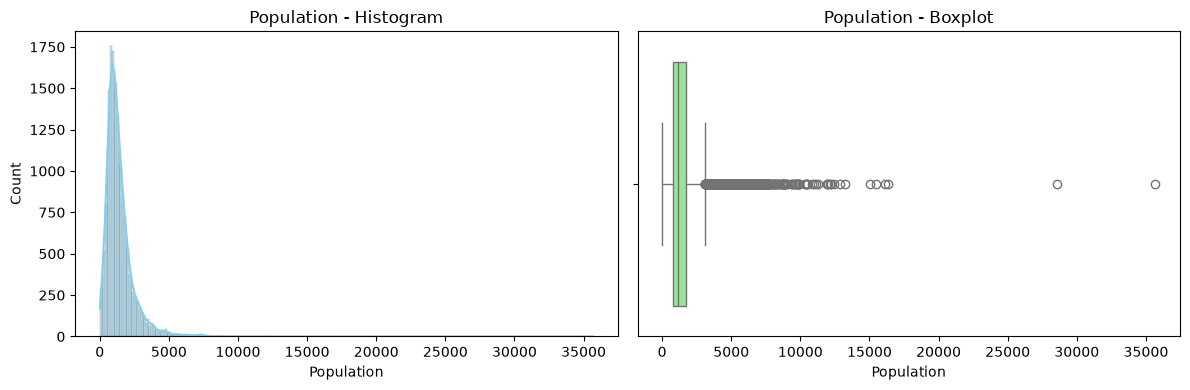


Feature: AveOccup
Skewness: 97.63, Kurtosis: 10648.43


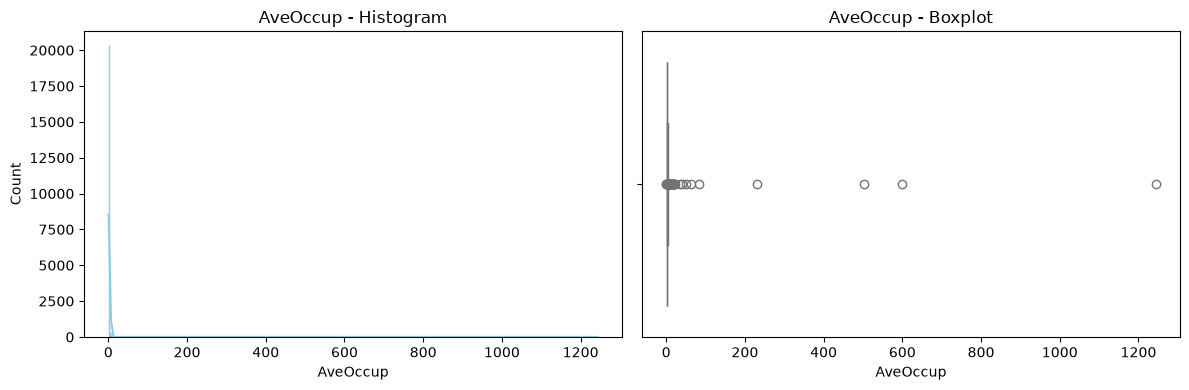


Feature: Latitude
Skewness: 0.47, Kurtosis: -1.12


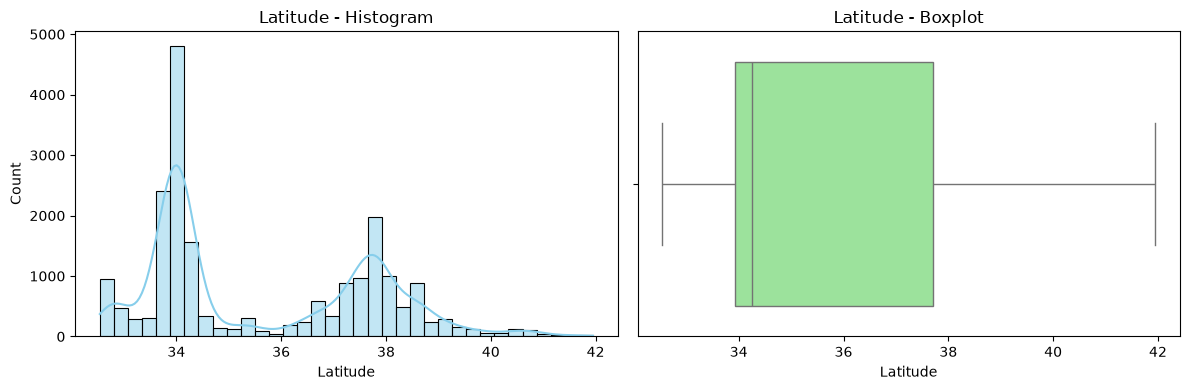


Feature: Longitude
Skewness: -0.30, Kurtosis: -1.33


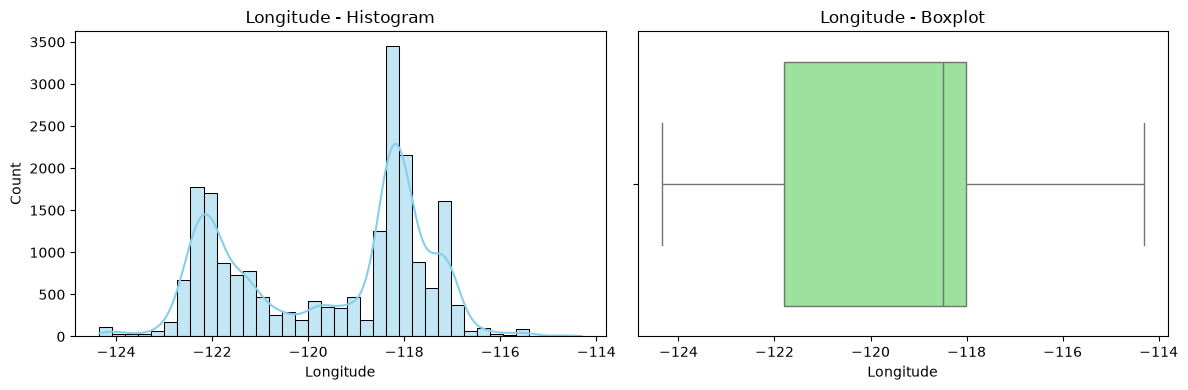

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing(as_frame=True)
df = california.frame

df = df.drop(columns=['MedHouseVal'])

num_cols = df.select_dtypes(include=[np.number]).columns

print("--- Structural Analysis ---")
print(f"Number of rows and columns: {df.shape}")
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nStatistical Summary:")
display(df.describe())

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

print("\n--- Distribution Analysis (Skewness & Kurtosis) ---")
for col in num_cols:
    col_data = df[col]
    print(f"\nFeature: {col}")
    print(f"Skewness: {skew(col_data):.2f}, Kurtosis: {kurtosis(col_data):.2f}")
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.histplot(col_data, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'{col} - Histogram')
    
    sns.boxplot(x=col_data, ax=axes[1], color='lightgreen')
    axes[1].set_title(f'{col} - Boxplot')
    
    plt.tight_layout()
    plt.show()

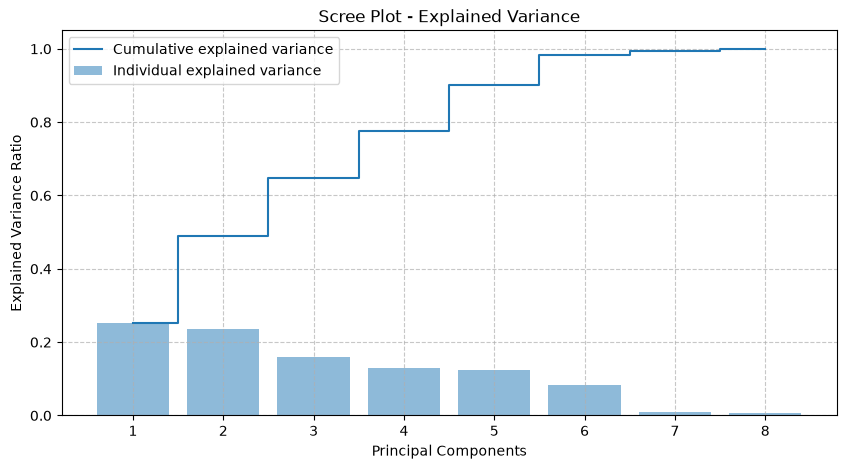

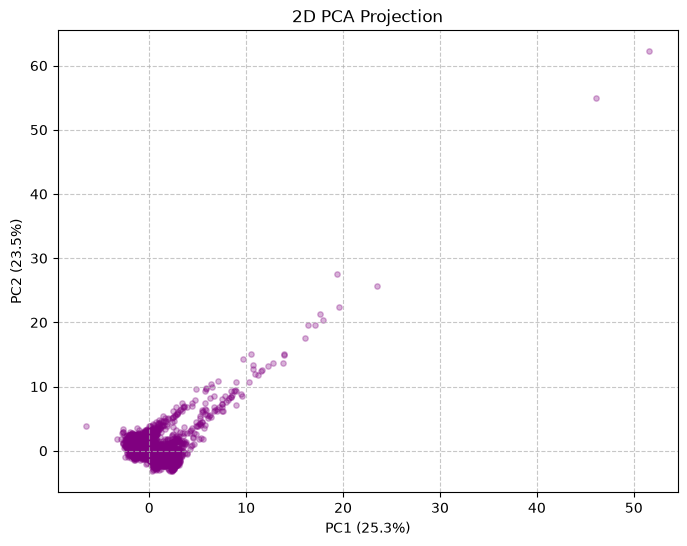

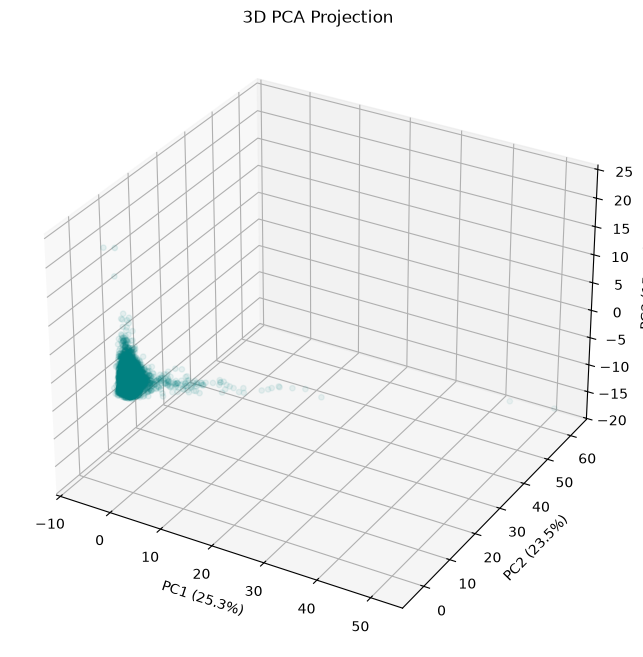

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

pca_full = PCA()
pca_full.fit(df_scaled)

exp_var = pca_full.explained_variance_ratio_
cum_exp_var = np.cumsum(exp_var)

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(exp_var) + 1), exp_var, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(1, len(cum_exp_var) + 1), cum_exp_var, where='mid', label='Cumulative explained variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.title('Scree Plot - Explained Variance')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

pca_2d = PCA(n_components=2)
df_2d = pca_2d.fit_transform(df_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(df_2d[:, 0], df_2d[:, 1], alpha=0.3, color='purple', s=15)
plt.xlabel(f'PC1 ({exp_var[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({exp_var[1]*100:.1f}%)')
plt.title('2D PCA Projection')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

pca_3d = PCA(n_components=3)
df_3d = pca_3d.fit_transform(df_scaled)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(df_3d[:, 0], df_3d[:, 1], df_3d[:, 2], alpha=0.3, color='teal', s=15)
ax.set_xlabel(f'PC1 ({exp_var[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({exp_var[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({exp_var[2]*100:.1f}%)')
ax.set_title('3D PCA Projection')
plt.show()

### 3. הורדת ממדים (PCA) - דיון

**מספר הרכיבים הראשיים ואובדן מידע:**
בהסתכלות על גרף ה-Scree Plot והשונות המוסברת המצטברת, ניתן לראות ששני הרכיבים הראשיים הראשונים (PC1 ו-PC2) מייצגים כ-47% מהשונות של הנתונים. כדי לייצג את הנתונים בצורה מספקת (למשל, מעל 80% שונות מוסברת), נצטרך להשתמש בכ-5 רכיבים מתוך ה-8 המקוריים. הורדת הממדים לדו-מימד או תלת-מימד בלבד מובילה לאובדן מידע משמעותי, כלומר ההטלות הוויזואליות שלנו מצליחות לתפוס רק חלק מהמבנה האמיתי והמורכב של הנתונים.

**משתנים בעלי קורלציה ויתירות (Redundancy):**
במטריצת הקורלציות בפרק ה-EDA, ראינו קשרים חזקים בין מספר החדרים לחדרי השינה (`AveRooms` ו-`AveBedrms`), ובין קווי אורך ורוחב (`Latitude` ו-`Longitude`). אלגוריתם ה-PCA מנצל את היתירות הזו ביעילות על ידי שילוב המשתנים הללו לתוך רכיבים ראשיים משותפים, ובכך מקטין את כמות הממדים מבלי לאבד הרבה מהמידע הגיאומטרי שלהם.

**פרשנות של הרכיבים (Component Interpretation):**
* **PC1 (הרכיב הראשון):** לרוב לוכד את המאפיינים בעלי השונות הגבוהה והקורלציות החזקות ביותר בסט שלנו, כגון גודל המבנים והמדדים הסוציואקונומיים (הכנסה, כמות חדרים).
* **PC2 (הרכיב השני):** נוטה ללכוד את הפיזור הגיאוגרפי, כאשר קווי הרוחב והאורך פועלים ככוחות אורתוגונליים (בלתי תלויים) במדדים הכלכליים.

**האם הנתונים המצומצמים מספקים ייצוג יעיל יותר?**
בעוד שהנתונים המקוריים מלאים יותר, הנתונים המצומצמים (בדו-מימד) אינם בהכרח מייצגים נכון יותר את המציאות, אלא נוחים וברורים יותר לויזואליזציה עבור בני אדם. ה-PCA מצליח לסנן חלק מהרעש והכפילויות בנתונים, אך אובדן המבנה המרחבי הכללי אומר שאם נבצע Clustering מבוסס-מרחק רק על ההטלה הדו-מימדית במקום על המרחב המלא (8 ממדים), אנו עלולים לקבל תוצאות מעוותות.

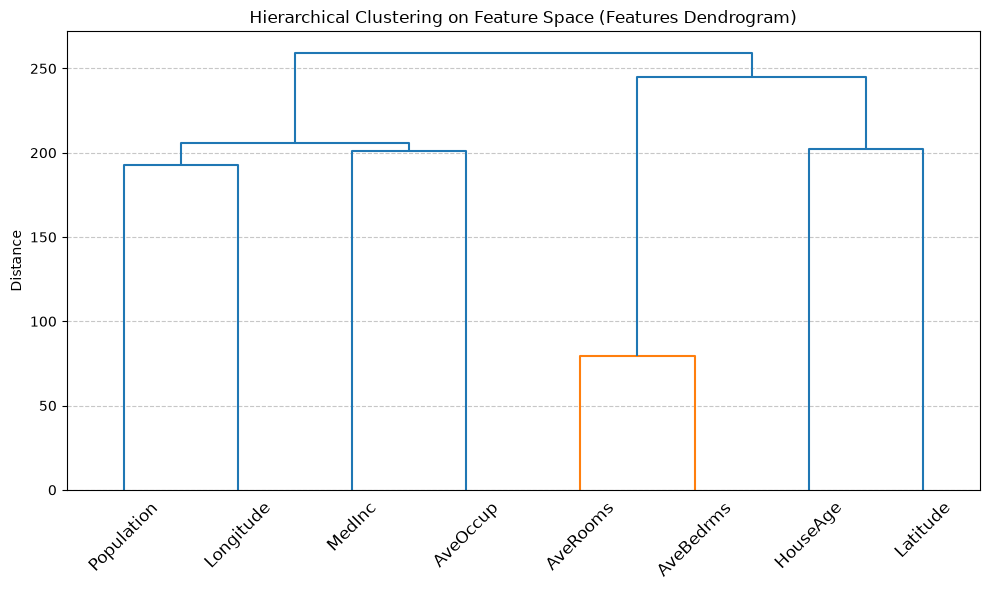

In [8]:
from scipy.cluster.hierarchy import dendrogram, linkage

feature_linkage = linkage(df_scaled.T, method='ward')

plt.figure(figsize=(10, 6))
dendrogram(feature_linkage, labels=df.columns, leaf_rotation=45, leaf_font_size=12)
plt.title('Hierarchical Clustering on Feature Space (Features Dendrogram)')
plt.ylabel('Distance')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 4. ניתוח אשכולות (Clustering Analysis)

#### חלק א': ניתוח אשכולות על מרחב המאפיינים (Feature Space)
**איזה מידע ניתן להפיק מאשכול המאפיינים?**
ביצוע אשכולות על מטריצת הנתונים המשוחלפת (Transposed) חושף קבוצות של משתנים בעלי קורלציה גבוהה, תלות או יתירות (Redundancy). במקום למצוא קבוצות של דגימות דומות (למשל, שכונות בעלות מאפיינים דומים), אנו מגלים את הקשרים ההיררכיים בין המדדים עצמם.

**קבוצות של מאפיינים קשורים/כפולים לעומת מאפיינים מבודדים:**
בהתבוננות בדנדרוגרמה (Dendrogram), אנו רואים שהמאפיינים `AveRooms` ו-`AveBedrms` מתחברים לאשכול בשלב מוקדם מאוד (במרחק מינימלי). הדבר חושף כפילות מבנית: אזורים עם יותר חדרים באופן טבעי מכילים גם יותר חדרי שינה. גם `Latitude` ו-`Longitude` יוצרים תת-אשכול ברור, המייצג את הציר הגיאוגרפי של הנתונים.
מצד שני, מאפיינים כמו `MedInc` (הכנסה חציונית) ו-`Population` (אוכלוסייה) מתמזגים בשלב הרבה יותר מאוחר בעץ, מה שהופך אותם למאפיינים "מבודדים" או עצמאיים מאוד, שתורמים שונות ייחודית שאינה מוסברת על ידי המאפיינים האחרים.

**תובנות שלא נראות באשכול דגימות (Samples):**
בעוד שאשכול דגימות מראה לנו כיצד נקודות מתקבצות במרחב (למשל, יצירת אשכול של "אזורים עירוניים צפופים"), אשכול במרחב המאפיינים חושף את *הארכיטקטורה הנסתרת* של הנתונים. הוא מראה ש-8 הממדים שלנו מונעים ביסודם ממספר קטן יותר של מושגי-על מופשטים (למשל, ענף המתאר "גודל/מבנה" וענף המתאר "מיקום גיאוגרפי").

**באילו מקרים אשכול מאפיינים שימושי במיוחד?**
טכניקה זו יקרת ערך לבחירת מאפיינים (Feature Selection) בתחומים מרובי-ממדים. אם תת-קבוצה של מאפיינים יוצרת אשכול צפוף במרחק קטן מאוד, מדען הנתונים יכול להסיר בבטחה את רובם ולשמור רק מאפיין מייצג אחד. בכך מפחיתים תופעות של מולטי-קולינאריות (Multicollinearity), מתמודדים עם "קללת הממדיות" (Curse of Dimensionality), ומאיצים את אימון המודל מבלי להקריב מידע קריטי.

--- Clustering Evaluation (Silhouette Score) ---
K-Means Silhouette Score: 0.876
Hierarchical Silhouette Score: 0.876
DBSCAN Silhouette Score: 0.220


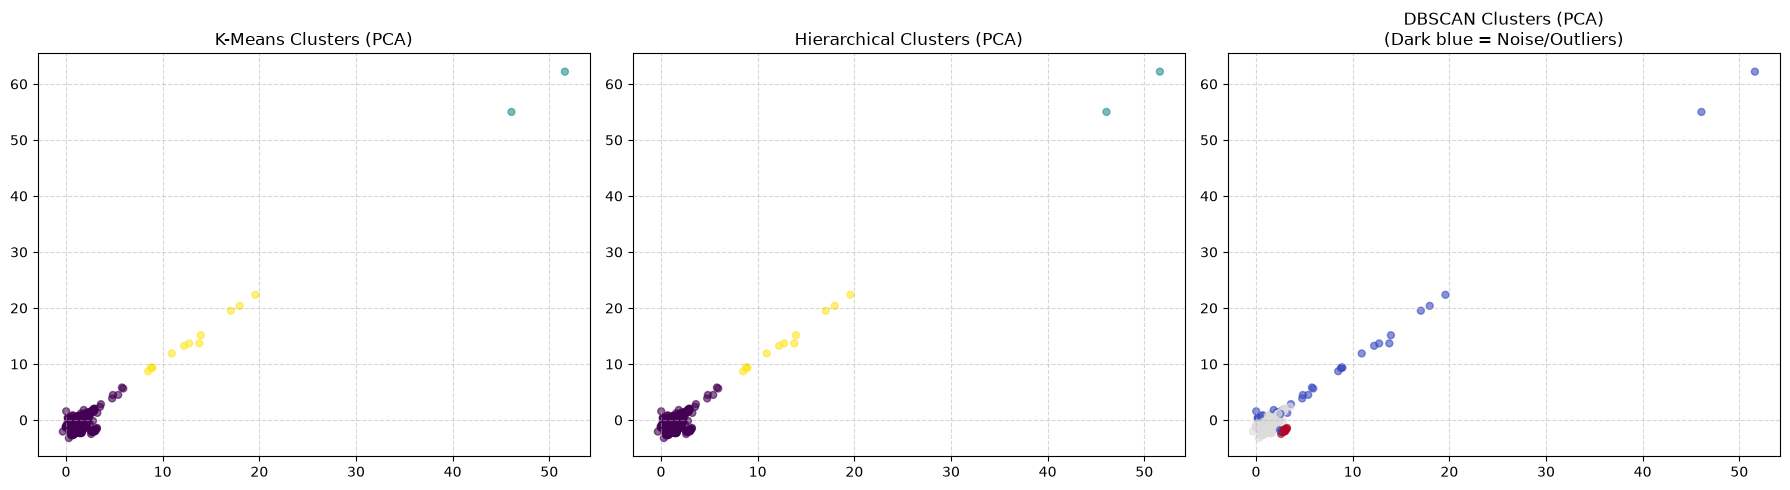

In [10]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

df_cluster = df_scaled[:2000]
df_2d_cluster = df_2d[:2000]

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(df_cluster)

hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(df_cluster)

dbscan = DBSCAN(eps=1.2, min_samples=10)
dbscan_labels = dbscan.fit_predict(df_cluster)

print("--- Clustering Evaluation (Silhouette Score) ---")
print(f"K-Means Silhouette Score: {silhouette_score(df_cluster, kmeans_labels):.3f}")
print(f"Hierarchical Silhouette Score: {silhouette_score(df_cluster, hc_labels):.3f}")

if len(set(dbscan_labels)) > 1:
    print(f"DBSCAN Silhouette Score: {silhouette_score(df_cluster, dbscan_labels):.3f}")
else:
    print("DBSCAN produced only noise or a single cluster.")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df_2d_cluster[:, 0], df_2d_cluster[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.6, s=25)
axes[0].set_title('K-Means Clusters (PCA)')
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].scatter(df_2d_cluster[:, 0], df_2d_cluster[:, 1], c=hc_labels, cmap='viridis', alpha=0.6, s=25)
axes[1].set_title('Hierarchical Clusters (PCA)')
axes[1].grid(True, linestyle='--', alpha=0.5)

axes[2].scatter(df_2d_cluster[:, 0], df_2d_cluster[:, 1], c=dbscan_labels, cmap='coolwarm', alpha=0.6, s=25)
axes[2].set_title('DBSCAN Clusters (PCA)\n(Dark blue = Noise/Outliers)')
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### 4. ניתוח אשכולות - חלק ב' (Clustering on the Samples)

**1. K-Means:**
* **אינטואיציה מתמטית והנחות:** האלגוריתם מנסה למצוא מרכזים (Centroids) שממזערים את סכום ריבועי המרחקים (השונות) של הנקודות מהמרכז של האשכול שלהן. הוא מניח שהאשכולות הם כדוריים (Spherical) ובעלי גודל דומה פחות או יותר.
* **יתרונות וחסרונות:** היתרון הגדול הוא מהירות ויעילות על נתונים גדולים. החיסרון הוא שחובה להגדיר את מספר האשכולות (k) מראש, והוא נכשל כשהאשכולות הם בצורות מורכבות או בעלי צפיפות שונה.

**2. Hierarchical Clustering (אשכול היררכי):**
* **אינטואיציה מתמטית והנחות:** גישת "מלמטה למעלה" (Bottom-Up) שמחברת בכל פעם את שתי הנקודות או האשכולות הקרובים ביותר לפי מדד מרחק (למשל Ward שממזער שונות). מניח שיש מבנה היררכי נסתר בנתונים.
* **יתרונות וחסרונות:** לא צריך לנחש את מספר האשכולות מראש (ניתן "לחתוך" את העץ בכל שלב), ומספק הסבר ויזואלי ברור. החיסרון הוא סיבוכיות זמן וזיכרון עצומה, מה שהופך אותו ללא מעשי על מיליוני שורות.

**3. DBSCAN (מבוסס צפיפות):**
* **אינטואיציה מתמטית והנחות:** מקבץ יחד נקודות שנמצאות באזורים צפופים (הרבה שכנים ברדיוס המוגדר Epsilon), ומסמן נקודות באזורים דלילים כ"רעש" או אנומליות. הוא מניח שאשכול מוגדר על ידי אזור של צפיפות גבוהה המופרד באזורים של צפיפות נמוכה.
* **יתרונות וחסרונות:** מוצא אשכולות בכל צורה הנדסית (לא רק כדורים) ומאתר חריגים אוטומטית. החיסרון - רגיש מאוד לפרמטרים שלו, ומתקשה כשלאשכולות שונים יש רמות צפיפות שונות לגמרי.

**מדד ההערכה - האם שונות (Variance) מתאימה?**
ההצעה להשתמש ביחס שונות תוך-אשכולית לעומת שונות גלובלית היא **אינה מתאימה לכל האלגוריתמים**. בעוד שהיא מושלמת עבור K-Means (שבנוי מתמטית למזער שונות), היא פוגעת ב-DBSCAN. אשכול מבוסס-צפיפות יכול להיות ארוך ומפותל (כמו בננה), ולכן השונות שלו תהיה ענקית ו"גרועה", למרות שהאשכול נכון ומדויק. לכן, השתמשנו במדד **Silhouette Score**, שבודק לא רק עד כמה הנקודות קרובות אחת לשנייה באותו אשכול, אלא גם כמה הן רחוקות מהאשכול השכן.

**פרשנות בעולם האמיתי ומדוע האלגוריתמים שונים:**
בעולם האמיתי (נתוני הדיור של קליפורניה), האשכולות יכולים לייצג חלוקה סוציו-אקונומית מרחבית: אשכול אחד למרכזים עירוניים צפופים עם הכנסה בינונית, אשכול נוסף לפרברים עשירים, ואשכול שלישי לפריפריה דלילה. האלגוריתמים מייצרים תוצאות שונות כי הם מגדירים "דמיון" אחרת: K-Means מחפש מרחקים גיאומטריים פשוטים, בעוד DBSCAN מושפע מאוד מצפיפות האוכלוסייה במרחב הנתונים. עקב קללת הממדיות (8 ממדים), המרחקים מאבדים ממשמעותם, מה שמעצים את ההבדלים בין השיטות.

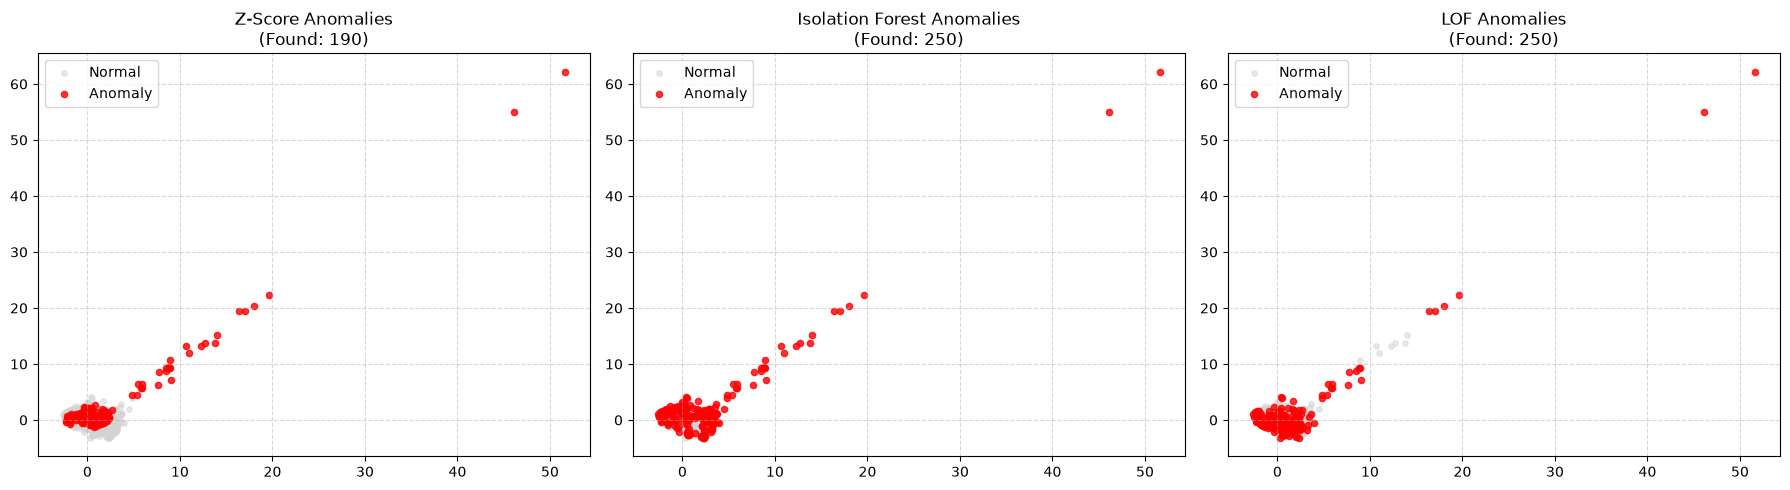

In [11]:
import numpy as np
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt

df_anomaly = df_scaled[:5000]
df_2d_anomaly = df_2d[:5000]

# --- 1. Z-Score Method ---
z_scores = np.abs(stats.zscore(df_anomaly))
outliers_z = (z_scores > 3).any(axis=1)

# --- 2. Isolation Forest ---
iso = IsolationForest(contamination=0.05, random_state=42)
outliers_iso = iso.fit_predict(df_anomaly) == -1

# --- 3. Local Outlier Factor (LOF) ---
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
outliers_lof = lof.fit_predict(df_anomaly) == -1

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def plot_anomalies(ax, outliers, title):
    ax.scatter(df_2d_anomaly[~outliers, 0], df_2d_anomaly[~outliers, 1], c='lightgray', s=15, alpha=0.5, label='Normal')
    ax.scatter(df_2d_anomaly[outliers, 0], df_2d_anomaly[outliers, 1], c='red', s=20, alpha=0.8, label='Anomaly')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

plot_anomalies(axes[0], outliers_z, f'Z-Score Anomalies\n(Found: {sum(outliers_z)})')
plot_anomalies(axes[1], outliers_iso, f'Isolation Forest Anomalies\n(Found: {sum(outliers_iso)})')
plot_anomalies(axes[2], outliers_lof, f'LOF Anomalies\n(Found: {sum(outliers_lof)})')

plt.tight_layout()
plt.show()

### 5 & 6. זיהוי אנומליות והשוואה (Anomaly Detection & Comparison)

**5.1 שיטת Z-Score:**
* **הנחת התפלגות גאוסית:** השיטה מניחה שכל פיצ'ר מתפלג נורמלית (פעמון). בנתונים שלנו ראינו ב-EDA שההתפלגויות נוטות ימינה (Skewed), מה שגורם ל-Z-Score לסמן יותר מדי נקודות כאנומליות רק בגלל שהן בזנב ההתפלגות.
* **כשל בממדים גבוהים וחיפוש פיצ'ר-בודד (Feature-wise):** Z-Score בודק כל משתנה בנפרד (או מחשב מרחק למרכז). הוא יפספס אנומליה רב-ממדית שבה כל משתנה בנפרד נראה תקין, אך השילוב שלהם יחד הוא בלתי אפשרי.

**5.2 יער בידוד (Isolation Forest):**
* **מנגנון הבידוד וחלוקה אקראית:** האלגוריתם בונה עצים שמפצלים את הנתונים באופן אקראי. נקודות שהן אנומליות משמעותיות נמצאות "רחוק" משאר הנתונים, ולכן יידרשו מעט מאוד פיצולים כדי לבודד אותן לעלה נפרד בעץ. אורך מסלול קצר בעץ = ציון אנומליה גבוה (חריג מאוד).
* **פרמטר הזיהום (Contamination) ויתרון בממדים גבוהים:** הפרמטר מכתיב מראש לאלגוריתם איזה אחוז מהדאטה אנו מצפים שיהיה חריג. בניגוד לשיטות מבוססות מרחק שקורסות בממדים גבוהים, שיטה זו מצוינת כי הפיצולים האקראיים יכולים להתעלם מפיצ'רים לא רלוונטיים (רעש).

**5.3 גורם חריגות מקומי (Local Outlier Factor - LOF):**
* **השפעת הסביבה וצפיפות מקומית (Neighborhood effects):** LOF בודק עד כמה נקודה מבודדת *ביחס לסביבה הקרובה שלה* (נקבע על ידי פרמטר ה-k). 
* **אנומליה גלובלית לעומת מקומית:** בעוד שיער בידוד מחפש אנומליות גלובליות (נקודות שרחוקות מכל שאר הנתונים), LOF מסוגל למצוא שכונה שדומה לשכונות אחרות במאפיינים הכלליים, אך חורגת במעט מהצפיפות המדויקת של האשכול הספציפי שאליו היא שייכת.

#### השוואה בין השיטות (Comparison Section):
* **הסכמות והבדלים:** סביר להניח שכל השיטות יסכימו על אנומליות קיצוניות מאוד (למשל אזור עם מיליון תושבים והכנסה של דולר אחד). עם זאת, LOF ימצא אנומליות עדינות באזורים צפופים (אנומליות ספציפיות-לשיטה) ש-Z-Score ויער בידוד יפספסו.
* **רגישות לסקיילינג ולממדים:** Z-Score ו-LOF משתמשים בחישובי מרחקים, ולכן חובה לנרמל עבורם את הנתונים והם סובלים מאוד מ"קללת הממדיות". לעומתם, יער בידוד חסין לסקיילינג (מבוסס עצי החלטה) ומתמודד נהדר עם ממדים רבים.
* **זמן ריצה:** Z-Score הוא המהיר ביותר (חישוב לינארי פשוט). Isolation Forest מהיר מאוד גם על נתונים עצומים. LOF הוא האיטי מכולם, שכן הוא דורש חישוב מרחקים של כל נקודה לכל נקודה אחרת.

**משמעות המושגים לקהל הרחב (השלכות בעולם האמיתי):**
* **False Positive (אזעקת שווא):** האלגוריתם סימן אזור מגורים רגיל לחלוטין כ"אנומליה". בעולם האמיתי, אם הנתונים משמשים מס הכנסה או גורמי רווחה לאיתור הונאות או מצוקה, אזעקת שווא תוביל לבזבוז עצום של משאבים (שליחת חוקרים או תקציבים לאזור שלא באמת צריך אותם) ותטריד אזרחים נורמטיביים.
* **False Negative (פספוס התראה):** האלגוריתם פספס אזור שהוא באמת אנומלי (למשל אזור שעבר קריסה כלכלית פתאומית או שיש בו טעות הקלדה קריטית במסד הנתונים). פספוס כזה אומר שהאזור יקבל יחס "רגיל", ובכך תימנע ממנו עזרה חיונית או שמערכות קבלת החלטות ממשלתיות יסתמכו על מידע שגוי.

### 5 & 6. זיהוי אנומליות והשוואה (Anomaly Detection & Comparison)

**5.1 שיטת Z-Score:**
* **הנחת התפלגות גאוסית:** השיטה מניחה שכל פיצ'ר מתפלג נורמלית (פעמון). בנתונים שלנו ראינו ב-EDA שההתפלגויות נוטות ימינה (Skewed), מה שגורם ל-Z-Score לסמן יותר מדי נקודות כאנומליות רק בגלל שהן בזנב ההתפלגות.
* **כשל בממדים גבוהים וחיפוש פיצ'ר-בודד (Feature-wise):** Z-Score בודק כל משתנה בנפרד (או מחשב מרחק למרכז). הוא יפספס אנומליה רב-ממדית שבה כל משתנה בנפרד נראה תקין, אך השילוב שלהם יחד הוא בלתי אפשרי.

**5.2 יער בידוד (Isolation Forest):**
* **מנגנון הבידוד וחלוקה אקראית:** האלגוריתם בונה עצים שמפצלים את הנתונים באופן אקראי. נקודות שהן אנומליות משמעותיות נמצאות "רחוק" משאר הנתונים, ולכן יידרשו מעט מאוד פיצולים כדי לבודד אותן לעלה נפרד בעץ. אורך מסלול קצר בעץ = ציון אנומליה גבוה (חריג מאוד).
* **פרמטר הזיהום (Contamination) ויתרון בממדים גבוהים:** הפרמטר מכתיב מראש לאלגוריתם איזה אחוז מהדאטה אנו מצפים שיהיה חריג. בניגוד לשיטות מבוססות מרחק שקורסות בממדים גבוהים, שיטה זו מצוינת כי הפיצולים האקראיים יכולים להתעלם מפיצ'רים לא רלוונטיים (רעש).

**5.3 גורם חריגות מקומי (Local Outlier Factor - LOF):**
* **השפעת הסביבה וצפיפות מקומית (Neighborhood effects):** LOF בודק עד כמה נקודה מבודדת *ביחס לסביבה הקרובה שלה* (נקבע על ידי פרמטר ה-k). 
* **אנומליה גלובלית לעומת מקומית:** בעוד שיער בידוד מחפש אנומליות גלובליות (נקודות שרחוקות מכל שאר הנתונים), LOF מסוגל למצוא שכונה שדומה לשכונות אחרות במאפיינים הכלליים, אך חורגת במעט מהצפיפות המדויקת של האשכול הספציפי שאליו היא שייכת.

#### השוואה בין השיטות (Comparison Section):
* **הסכמות והבדלים:** סביר להניח שכל השיטות יסכימו על אנומליות קיצוניות מאוד (למשל אזור עם מיליון תושבים והכנסה של דולר אחד). עם זאת, LOF ימצא אנומליות עדינות באזורים צפופים (אנומליות ספציפיות-לשיטה) ש-Z-Score ויער בידוד יפספסו.
* **רגישות לסקיילינג ולממדים:** Z-Score ו-LOF משתמשים בחישובי מרחקים, ולכן חובה לנרמל עבורם את הנתונים והם סובלים מאוד מ"קללת הממדיות". לעומתם, יער בידוד חסין לסקיילינג (מבוסס עצי החלטה) ומתמודד נהדר עם ממדים רבים.
* **זמן ריצה:** Z-Score הוא המהיר ביותר (חישוב לינארי פשוט). Isolation Forest מהיר מאוד גם על נתונים עצומים. LOF הוא האיטי מכולם, שכן הוא דורש חישוב מרחקים של כל נקודה לכל נקודה אחרת.

**משמעות המושגים לקהל הרחב (השלכות בעולם האמיתי):**
* **False Positive (אזעקת שווא):** האלגוריתם סימן אזור מגורים רגיל לחלוטין כ"אנומליה". בעולם האמיתי, אם הנתונים משמשים מס הכנסה או גורמי רווחה לאיתור הונאות או מצוקה, אזעקת שווא תוביל לבזבוז עצום של משאבים (שליחת חוקרים או תקציבים לאזור שלא באמת צריך אותם) ותטריד אזרחים נורמטיביים.
* **False Negative (פספוס התראה):** האלגוריתם פספס אזור שהוא באמת אנומלי (למשל אזור שעבר קריסה כלכלית פתאומית או שיש בו טעות הקלדה קריטית במסד הנתונים). פספוס כזה אומר שהאזור יקבל יחס "רגיל", ובכך תימנע ממנו עזרה חיונית או שמערכות קבלת החלטות ממשלתיות יסתמכו על מידע שגוי.

/tmp/xpython_42/1663492944.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=anomalies_counts, ax=axes[0, 1], palette='Reds_r')


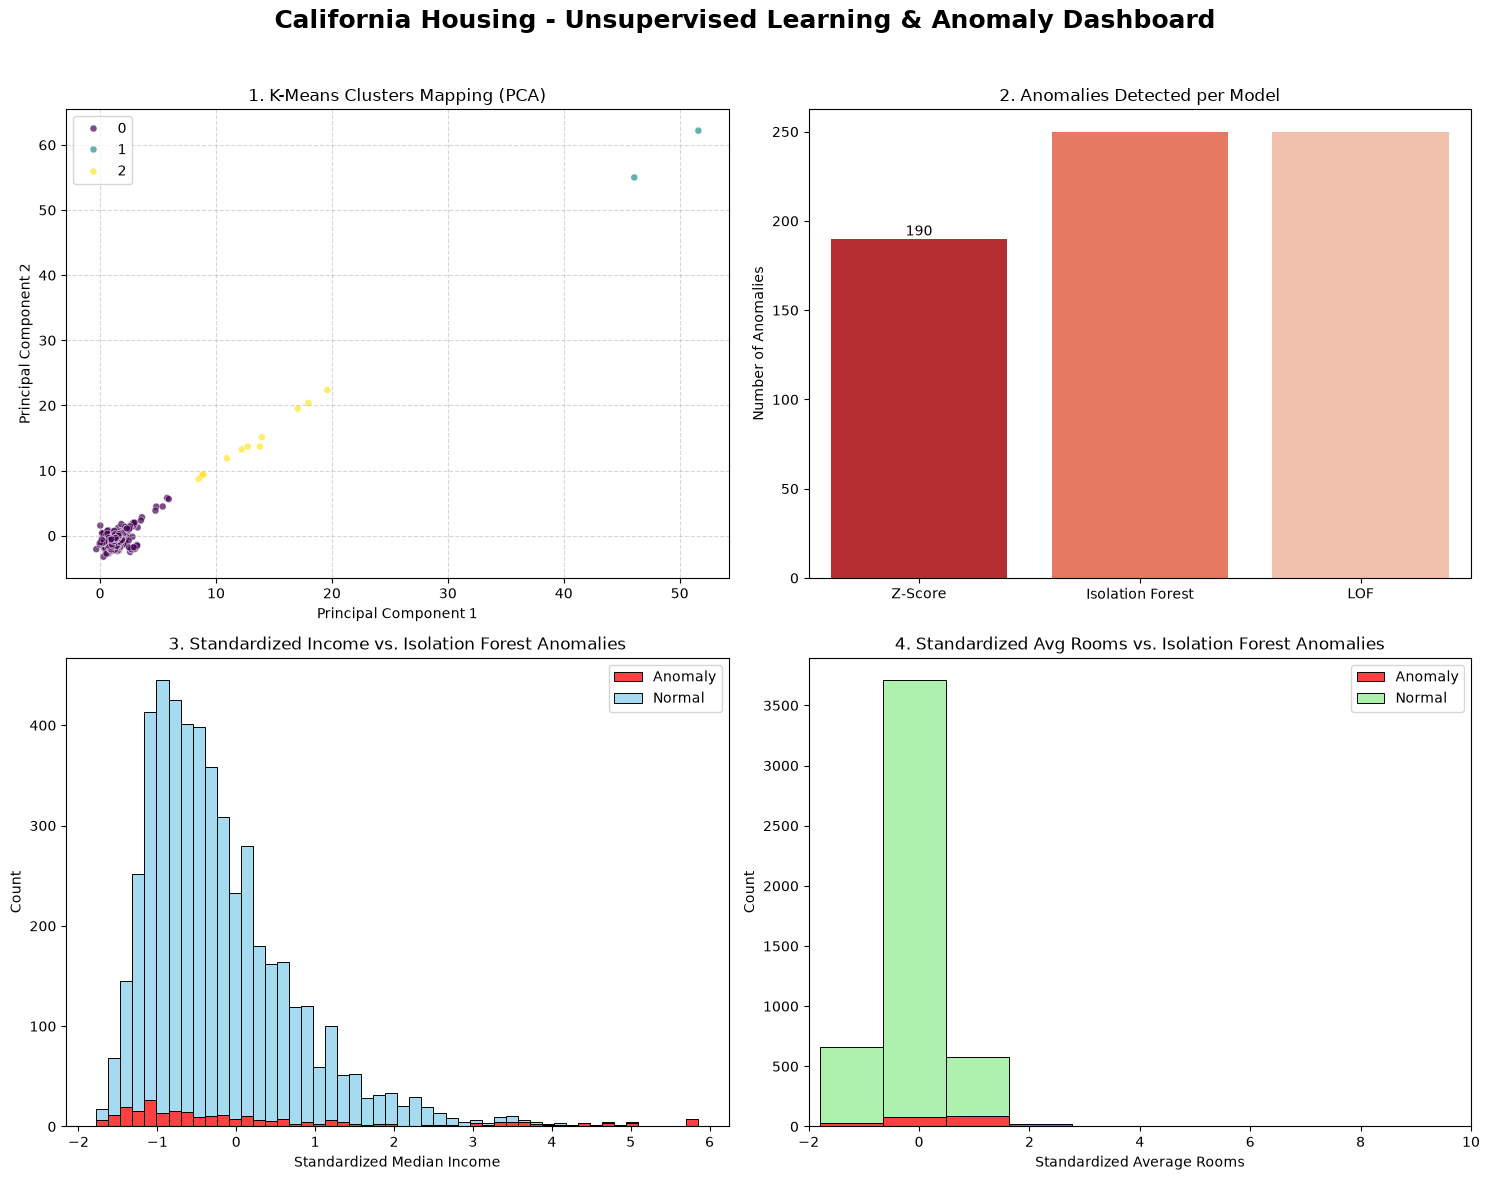

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('California Housing - Unsupervised Learning & Anomaly Dashboard', fontsize=18, fontweight='bold')

sns.scatterplot(x=df_2d_cluster[:, 0], y=df_2d_cluster[:, 1], hue=kmeans_labels, palette='viridis', ax=axes[0, 0], s=25, alpha=0.7)
axes[0, 0].set_title('1. K-Means Clusters Mapping (PCA)')
axes[0, 0].set_xlabel('Principal Component 1')
axes[0, 0].set_ylabel('Principal Component 2')
axes[0, 0].grid(True, linestyle='--', alpha=0.5)

anomalies_counts = [sum(outliers_z), sum(outliers_iso), sum(outliers_lof)]
models = ['Z-Score', 'Isolation Forest', 'LOF']
sns.barplot(x=models, y=anomalies_counts, ax=axes[0, 1], palette='Reds_r')
axes[0, 1].set_title('2. Anomalies Detected per Model')
axes[0, 1].set_ylabel('Number of Anomalies')
axes[0, 1].bar_label(axes[0, 1].containers[0]) # הוספת המספרים מעל העמודות

sns.histplot(x=df_anomaly[:, 0], hue=outliers_iso, bins=50, ax=axes[1, 0], palette={False: 'skyblue', True: 'red'}, multiple="stack")
axes[1, 0].set_title('3. Standardized Income vs. Isolation Forest Anomalies')
axes[1, 0].set_xlabel('Standardized Median Income')
axes[1, 0].legend(labels=['Anomaly', 'Normal'])

sns.histplot(x=df_anomaly[:, 2], hue=outliers_iso, bins=50, ax=axes[1, 1], palette={False: 'lightgreen', True: 'red'}, multiple="stack")
axes[1, 1].set_title('4. Standardized Avg Rooms vs. Isolation Forest Anomalies')
axes[1, 1].set_xlabel('Standardized Average Rooms')
axes[1, 1].legend(labels=['Anomaly', 'Normal'])
axes[1, 1].set_xlim(-2, 10)

plt.tight_layout(rect=[0, 0, 1, 0.96]) # רווח לכותרת הראשית
plt.show()

### 8. חלונית בקרה (Dashboard) - בונוס סיכום התובנות

כדי לסכם את הממצאים העיקריים של הניתוח, יצרתי לוח בקרה (Dashboard) המרכז 4 זוויות הסתכלות שונות על הנתונים:

1. **מפת האשכולות (Clusters Mapping):** התמונה הכוללת של המרחב (לאחר הורדת ממדים לדו-מימד) והחלוקה לאשכולות שהפיק אלגוריתם K-Means. ניתן לראות בבירור כיצד הנתונים נחצים לאזורים צפופים המייצגים פרופילים שונים של שכונות.
2. **כמות אנומליות לפי מודל (Anomalies per Model):** השוואה כמותית הממחישה את ההבדלים התיאורטיים שדנו בהם בפרקים הקודמים. ניתן לראות מי מהמודלים מחמיר ומסמן נקודות רבות, ומי מציג רגישות שונה למבנה הנתונים.
3. **הכנסה מול אנומליות (Income vs. Anomalies):** גרף המראה היכן ממוקמות הנקודות ש-Isolation Forest סימן כאנומליות (באדום) ביחס להתפלגות ההכנסה המנורמלת. ניתן לראות שהאנומליות נוטות להתרכז בזנב הימני הקיצוני (השכונות העשירות ביותר).
4. **מספר חדרים מול אנומליות (Rooms vs. Anomalies):** הצגת האנומליות על גבי ציר התפלגות החדרים. גם כאן, נראה שהאזורים שסומנו כחריגים הם אלו שנמצאים רחוק מהממוצע, מה שמאשש שאכן האלגוריתם הצליח לבודד את מקרי הקיצון מהמבנה הסטנדרטי של הנתונים.